Dataset loaded successfully.
Raw dataset shape: (50401, 300)

Raw date range:
First date: 2014-12-31T23:00:00Z
Last date : 2020-09-30T23:00:00Z

Germany-related columns:
DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation

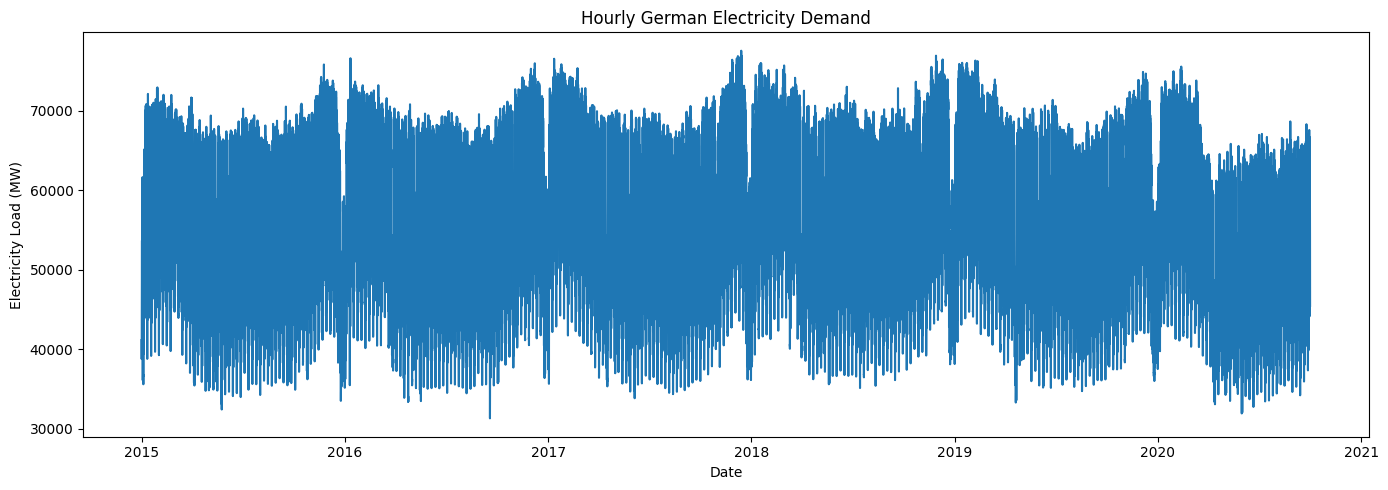

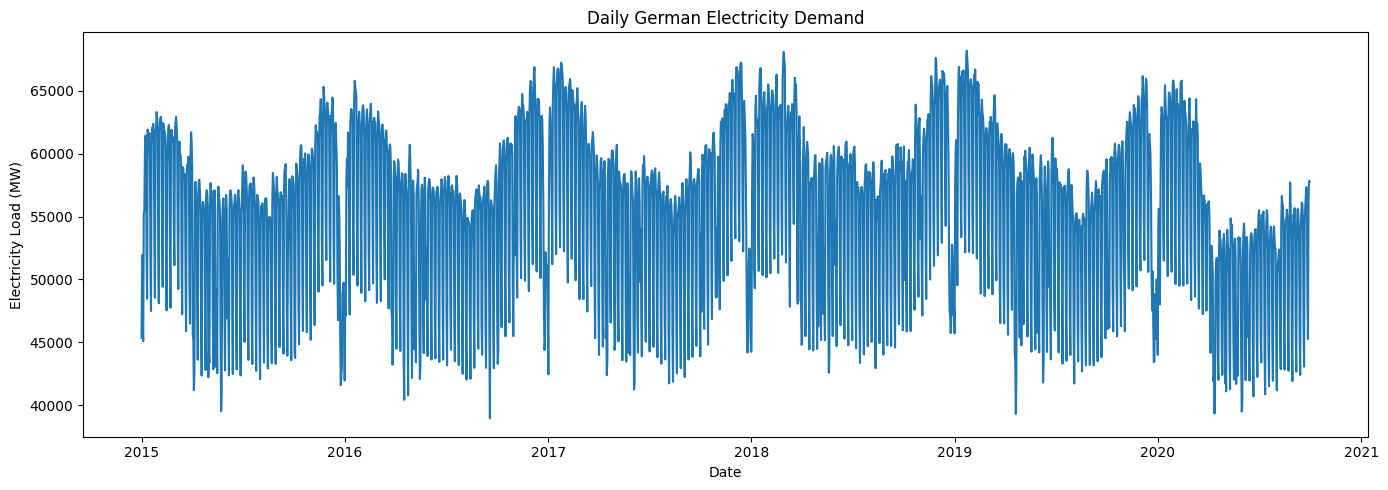

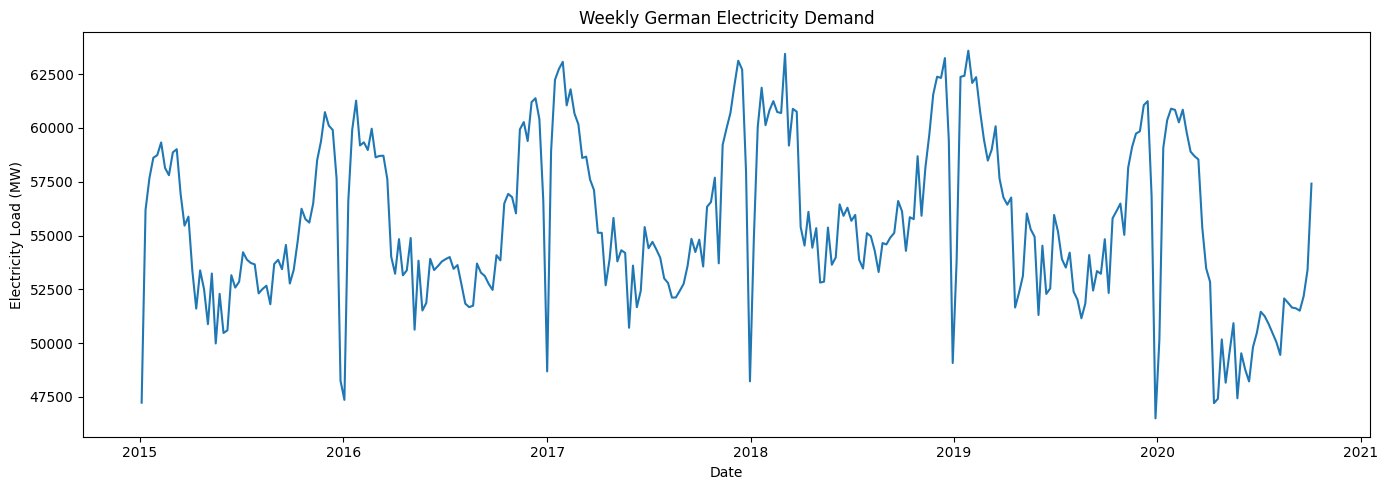


Data cleaning and resampling completed correctly.


In [4]:
# DATA CLEANING AND RESAMPLING FOR GERMAN ELECTRICITY DEMAND


import pandas as pd
import matplotlib.pyplot as plt
import os


# 1. Load the dataset


file_path = "time_series_60min_singleindex.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Raw dataset shape:", df_raw.shape)


# 2. Check date range of raw dataset

print("\nRaw date range:")
print("First date:", df_raw["utc_timestamp"].min())
print("Last date :", df_raw["utc_timestamp"].max())


# 3. Identify Germany demand column


germany_columns = [col for col in df_raw.columns if col.startswith("DE")]

print("\nGermany-related columns:")
for col in germany_columns:
    print(col)

germany_actual_load_columns = [
    col for col in df_raw.columns
    if col.startswith("DE")
    and "load_actual" in col.lower()
]

print("\nPossible German actual load columns:")
print(germany_actual_load_columns)

# Use national Germany demand column
load_column = "DE_load_actual_entsoe_transparency"

if load_column not in df_raw.columns:
    raise ValueError("German national demand column not found. Check column names.")

print("\nSelected German demand column:", load_column)


# 4. Keep only timestamp and German load column


df = df_raw[["utc_timestamp", load_column]].copy()

df.rename(columns={
    "utc_timestamp": "Date",
    load_column: "Load"
}, inplace=True)


# 5. Convert Date to datetime and set index

df["Date"] = pd.to_datetime(df["Date"], utc=True)
df.set_index("Date", inplace=True)


# 6. From 1 Jan 2015 to Oct 2020

df = df.loc["2015-01-01":"2020-10-31"].copy()

print("\nFiltered date range:")
print("First date:", df.index.min())
print("Last date :", df.index.max())


# 7. Sort index


df = df.sort_index()


# 8. Check duplicate timestamps

duplicate_timestamps = df.index.duplicated().sum()
print("\nDuplicate timestamps:", duplicate_timestamps)

if duplicate_timestamps > 0:
    df = df[~df.index.duplicated(keep="first")]


# 9. Check missing values

print("\nMissing values before treatment:")
print(df.isnull().sum())

# Time-based interpolation for continuous time series
df["Load"] = df["Load"].interpolate(method="time")
df["Load"] = df["Load"].ffill()
df["Load"] = df["Load"].bfill()

print("\nMissing values after treatment:")
print(df.isnull().sum())


# 10. Create daily and weekly datasets

daily_load = df.resample("D").mean()
weekly_load = df.resample("W").mean()


# 11. Print final checks


print("\nFinal hourly data:")
print(df.head())
print(df.tail())
print("Hourly shape:", df.shape)

print("\nFinal daily data:")
print(daily_load.head())
print(daily_load.tail())
print("Daily shape:", daily_load.shape)

print("\nFinal weekly data:")
print(weekly_load.head())
print(weekly_load.tail())
print("Weekly shape:", weekly_load.shape)


# 12. Save cleaned data


os.makedirs("processed_data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

df.to_csv("processed_data/hourly_germany_load.csv")
daily_load.to_csv("processed_data/daily_germany_load.csv")
weekly_load.to_csv("processed_data/weekly_germany_load.csv")

print("\nCleaned datasets saved successfully.")


# 13. Plot hourly, daily and weekly data

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Load"])
plt.title("Hourly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/hourly_german_electricity_demand.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(daily_load.index, daily_load["Load"])
plt.title("Daily German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/daily_german_electricity_demand.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(weekly_load.index, weekly_load["Load"])
plt.title("Weekly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/weekly_german_electricity_demand.png", dpi=300)
plt.show()

print("\nData cleaning and resampling completed correctly.")

In [5]:
df
daily_load
weekly_load

,Load
Date,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762
...,...
2020-09-06 00:00:00+00:00,51617.744048
2020-09-13 00:00:00+00:00,51507.630952
2020-09-20 00:00:00+00:00,52181.327381


Hourly shape: (50400, 1)
Daily shape : (2100, 1)
Weekly shape: (301, 1)

HOURLY SUMMARY STATISTICS
count    50400.000000
mean     55492.468552
std      10015.431042
min      31307.000000
25%      47106.000000
50%      55092.000000
75%      64309.250000
max      77549.000000
Name: Load, dtype: float64

DAILY SUMMARY STATISTICS
count     2100.000000
mean     55492.468552
std       6601.474342
min      38952.666667
25%      50413.447917
50%      56776.916667
75%      60430.093750
max      68183.583333
Name: Load, dtype: float64

WEEKLY SUMMARY STATISTICS
count      301.000000
mean     55484.350477
std       3762.742475
min      46505.309524
25%      52845.267857
50%      54858.434524
75%      58688.470238
max      63587.011905
Name: Load, dtype: float64

Missing values:
Hourly: 0
Daily : 0
Weekly: 0

Duplicate timestamps:
Hourly: 0
Daily : 0
Weekly: 0


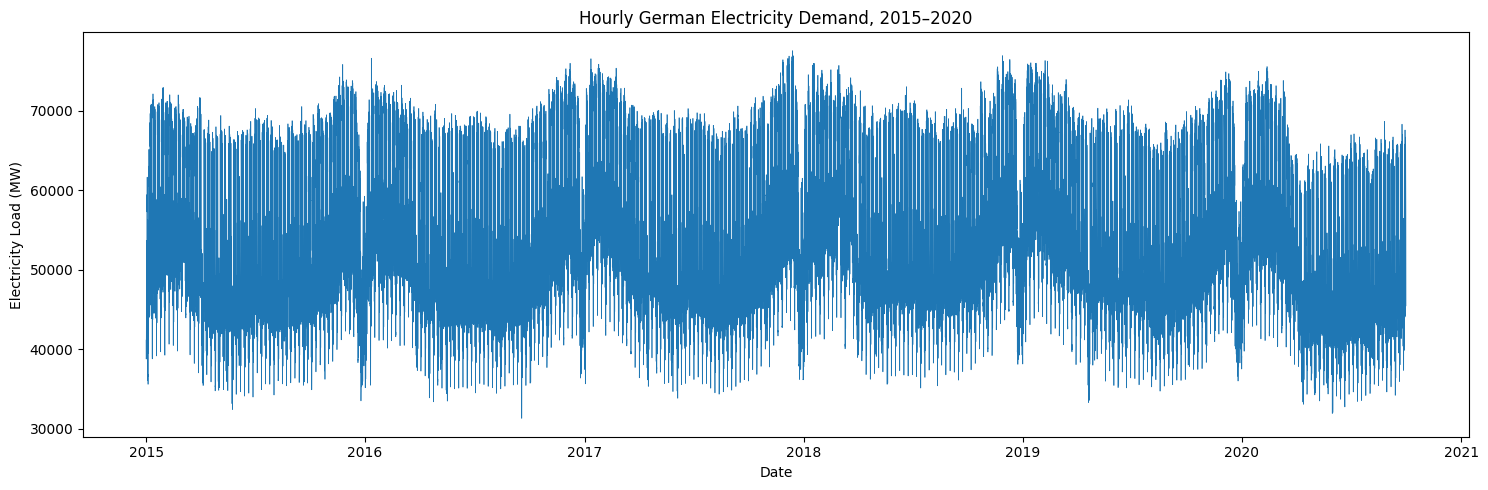

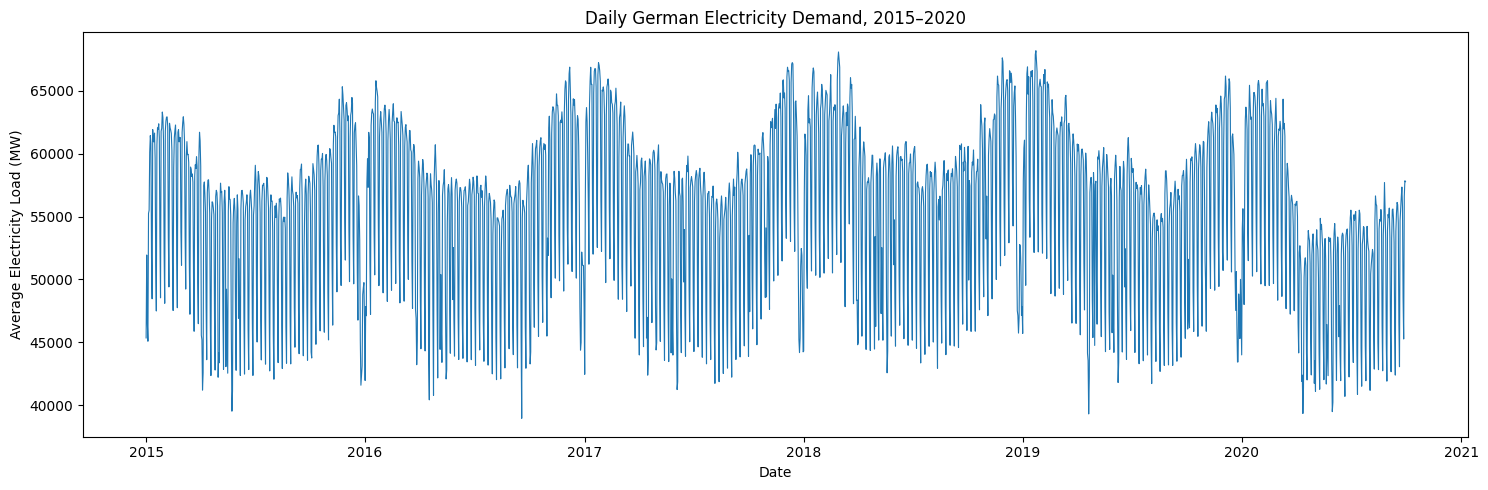

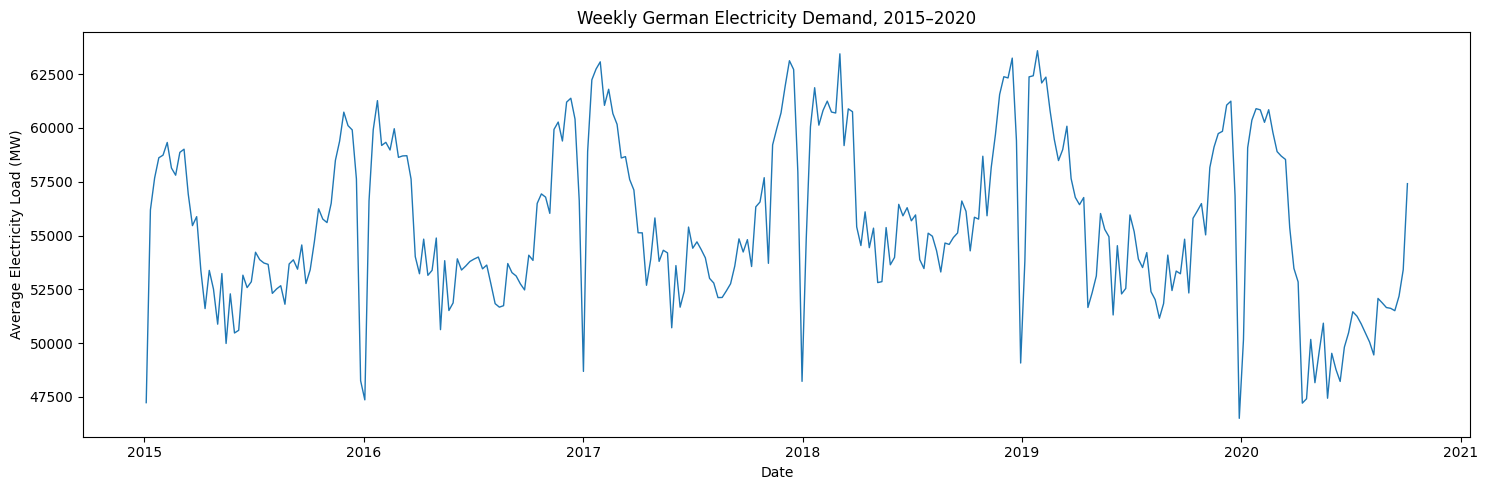

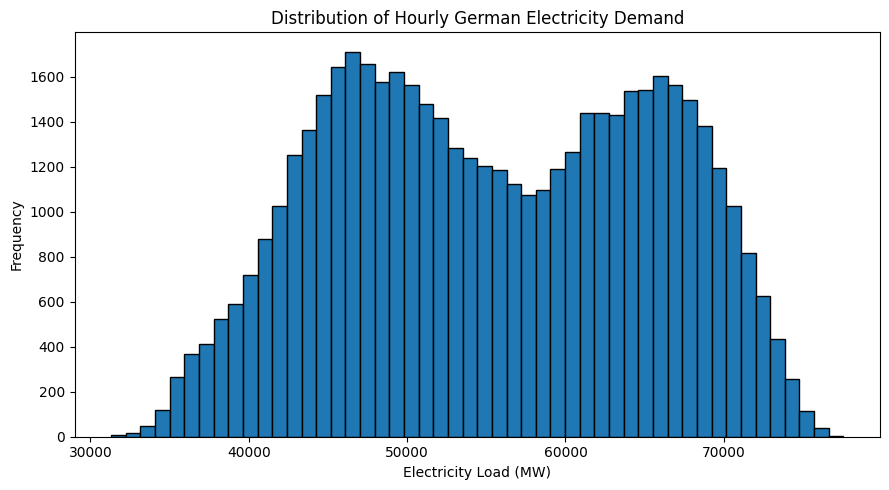

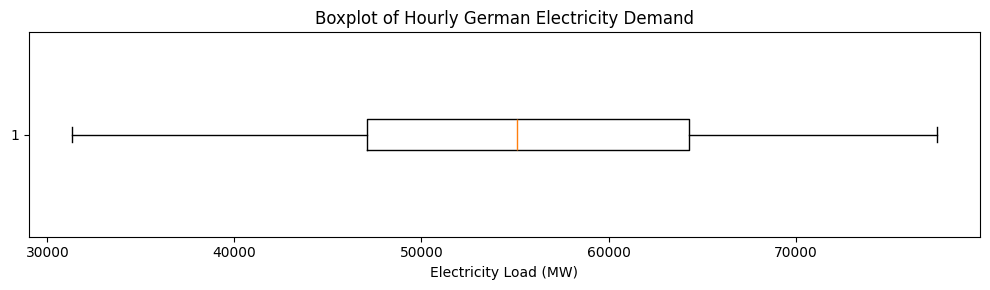

/tmp/ipykernel_2702/986032764.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(monthly_groups, labels=month_labels)


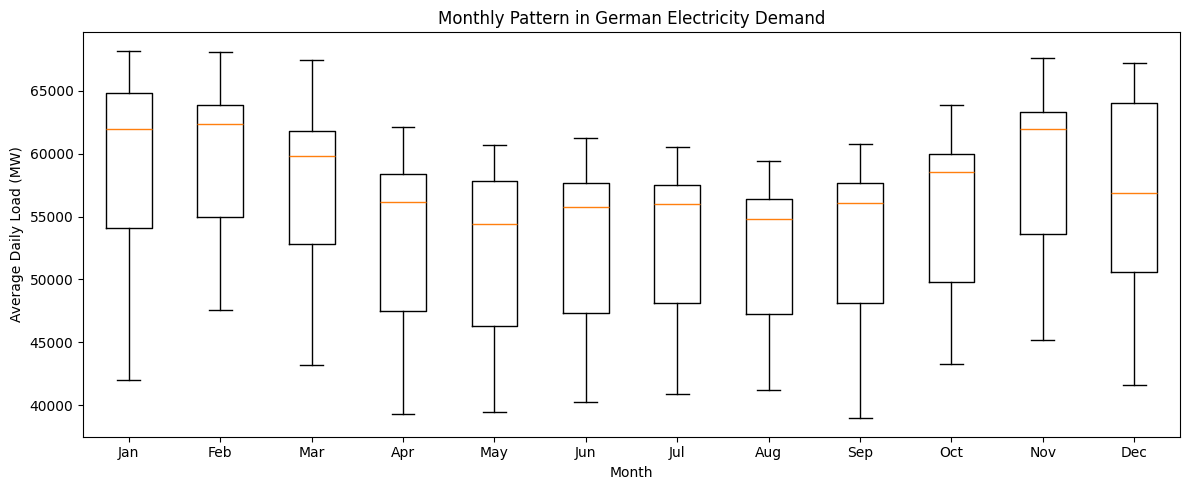

/tmp/ipykernel_2702/986032764.py:155: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(weekday_groups, labels=weekday_labels)


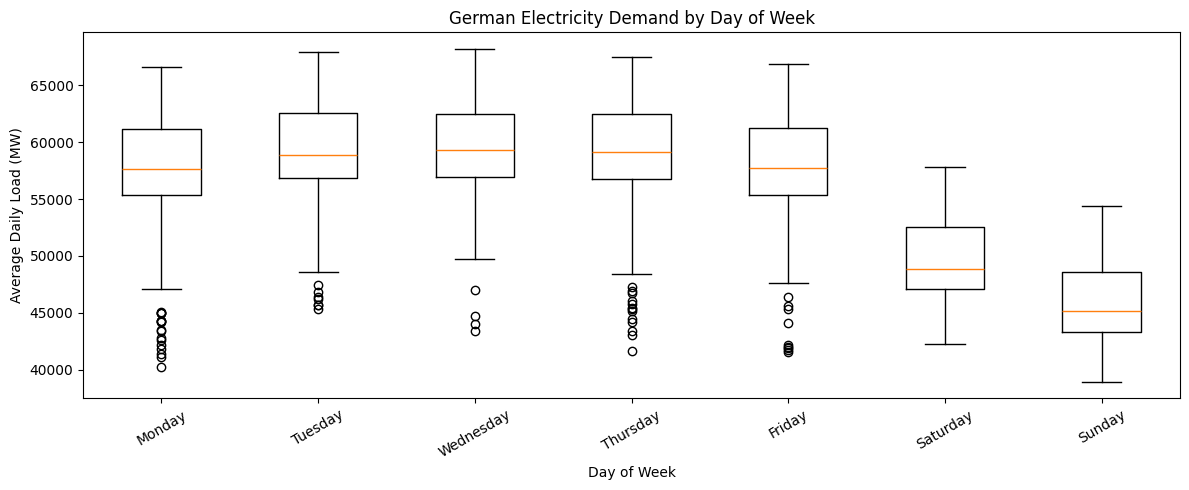

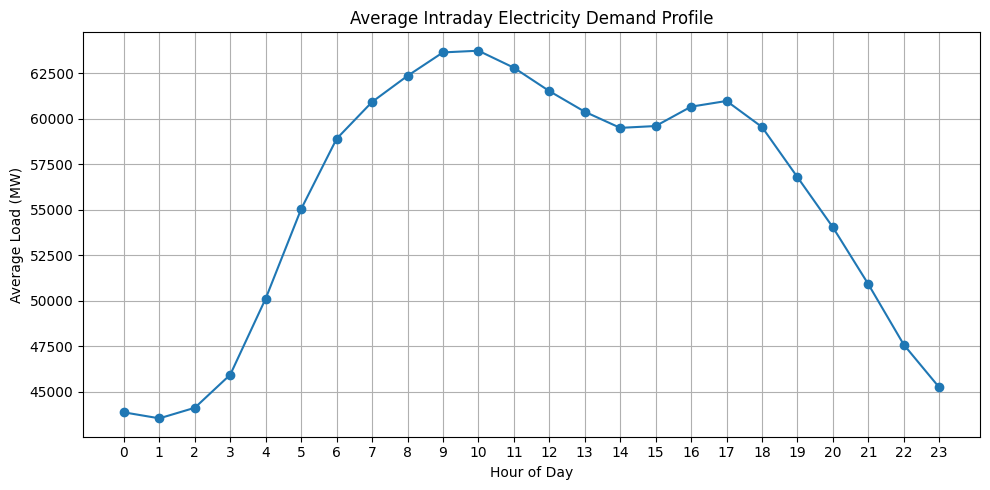

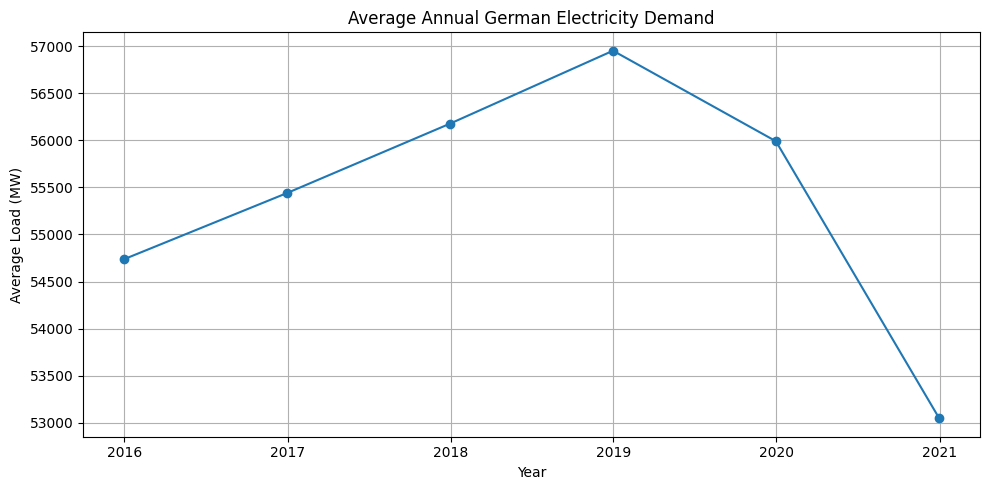

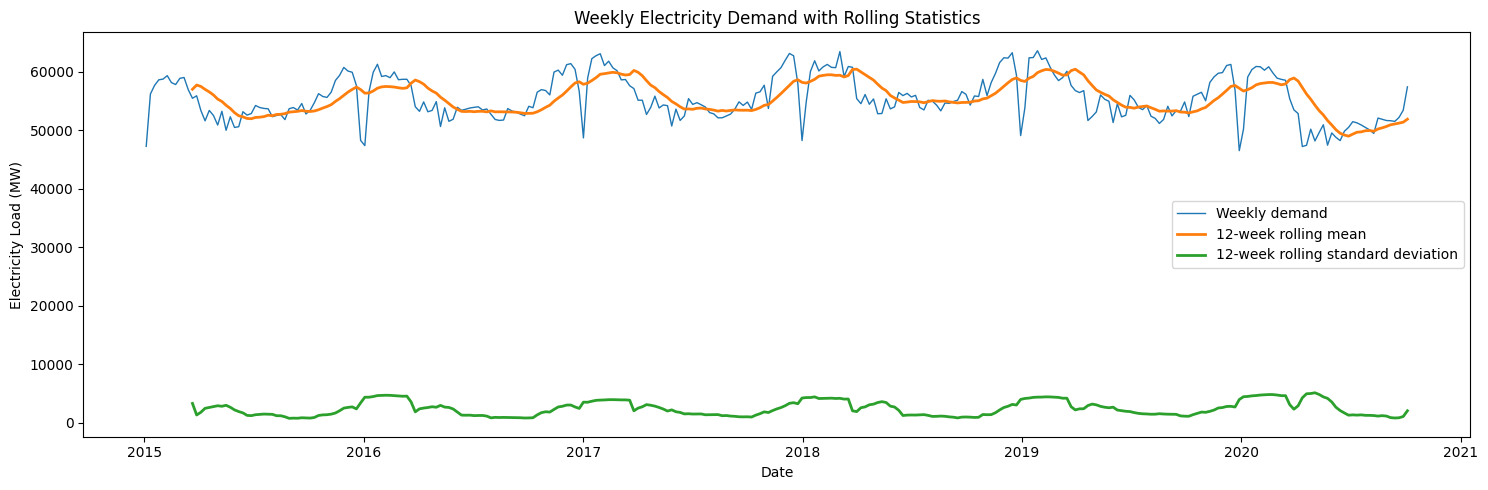

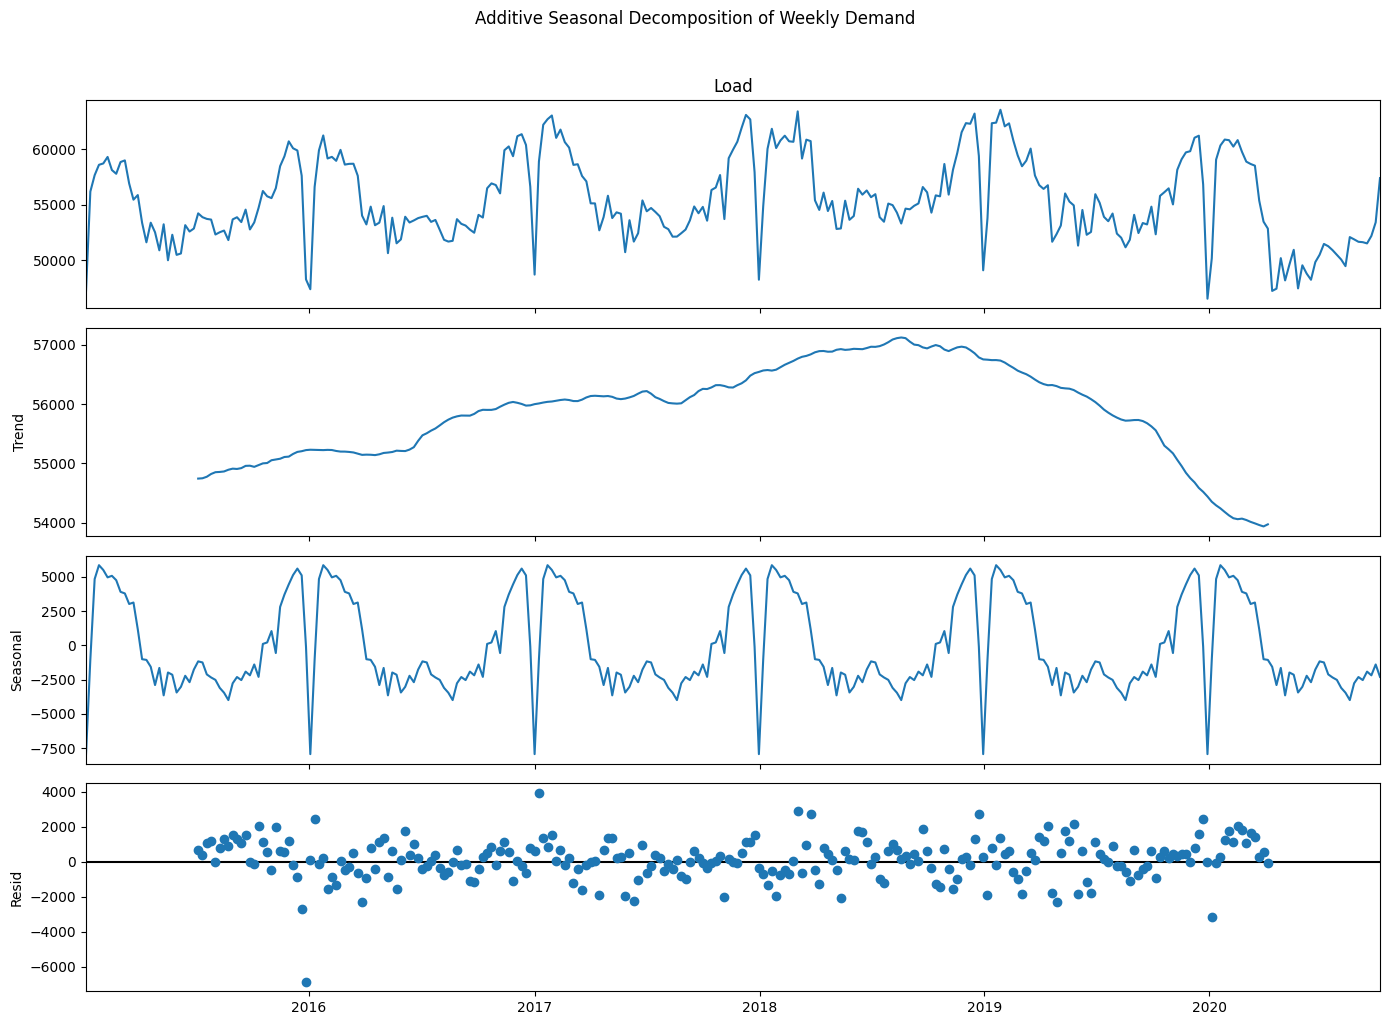

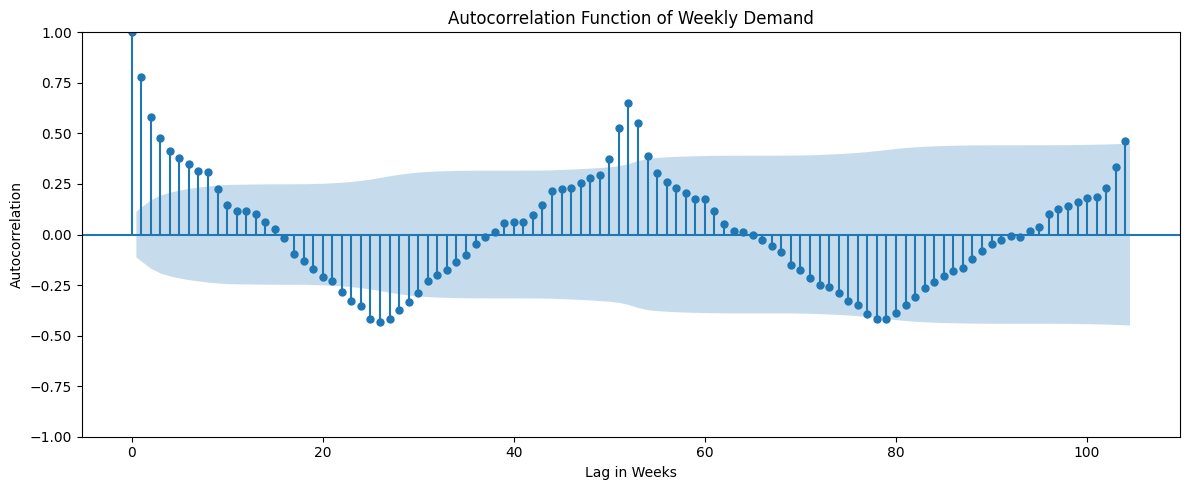

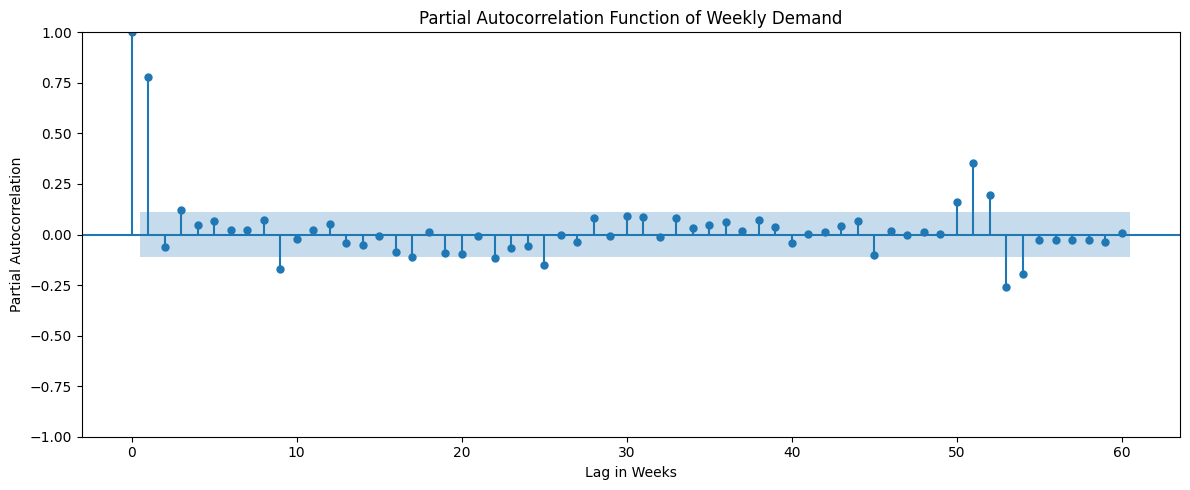


AUGMENTED DICKEY-FULLER TEST
ADF statistic             : -4.0475
P-value                   : 0.001181
Number of lags used       : 8
Number of observations    : 292

Critical values:
1%: -3.4529
5%: -2.8715
10%: -2.5721

Conclusion:
Reject the null hypothesis of a unit root.
The weekly electricity-demand series appears stationary.


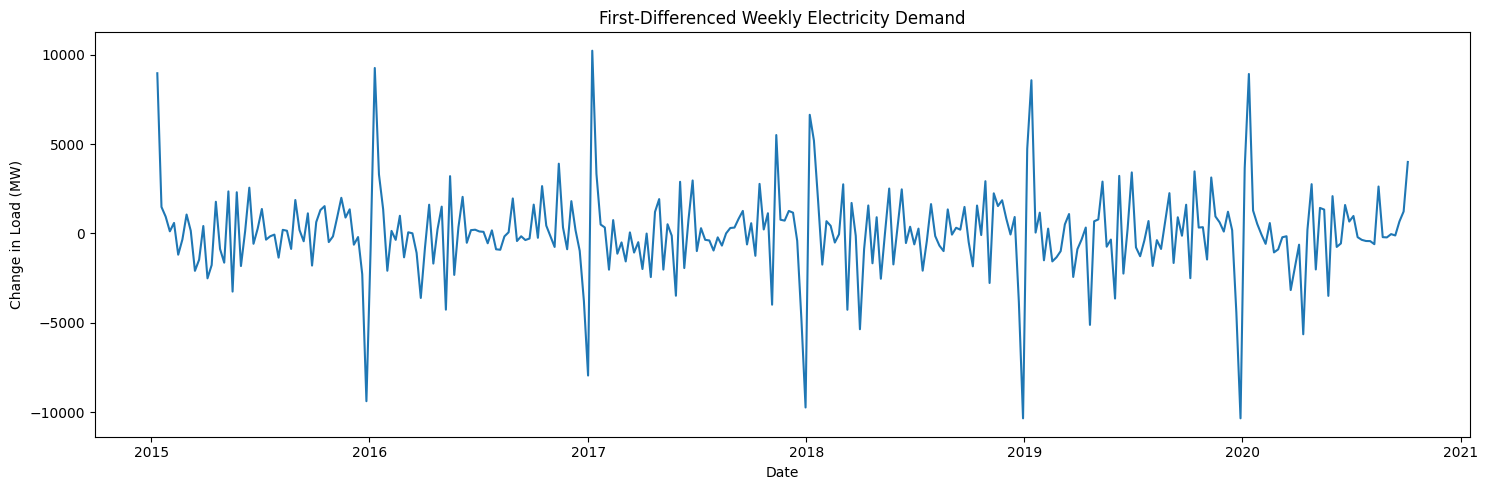


ADF TEST AFTER FIRST DIFFERENCING
ADF statistic : -7.0693
P-value       : 0.000000

The first-differenced series appears stationary.


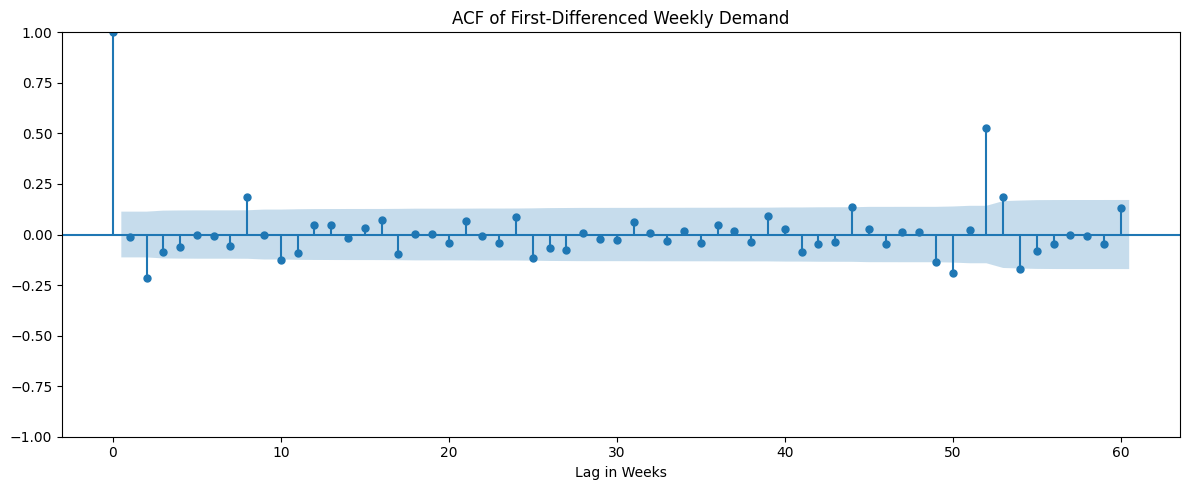

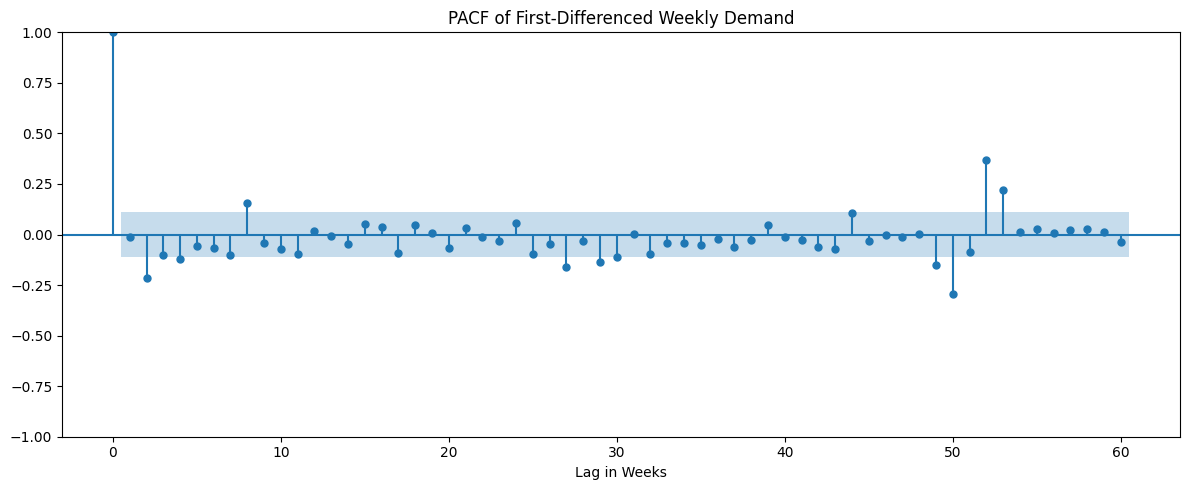


EDA and stationarity analysis completed successfully.
All figures were saved in the 'figures' folder.


In [7]:
# EXPLORATORY DATA ANALYSIS (EDA)
# German Electricity Demand

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


# 1. Reuse cleaned datasets from preprocessing


hourly = df.copy()
daily = daily_load.copy()
weekly = weekly_load.copy()

print("Hourly shape:", hourly.shape)
print("Daily shape :", daily.shape)
print("Weekly shape:", weekly.shape)

# Create a folder to save figures
os.makedirs("figures", exist_ok=True)

# 2. Summary statistics

print("\n" + "=" * 60)
print("HOURLY SUMMARY STATISTICS")
print("=" * 60)
print(hourly["Load"].describe())

print("\n" + "=" * 60)
print("DAILY SUMMARY STATISTICS")
print("=" * 60)
print(daily["Load"].describe())

print("\n" + "=" * 60)
print("WEEKLY SUMMARY STATISTICS")
print("=" * 60)
print(weekly["Load"].describe())

# 3. Missing-value and duplicate-timestamp checks

print("\nMissing values:")
print("Hourly:", hourly["Load"].isna().sum())
print("Daily :", daily["Load"].isna().sum())
print("Weekly:", weekly["Load"].isna().sum())

print("\nDuplicate timestamps:")
print("Hourly:", hourly.index.duplicated().sum())
print("Daily :", daily.index.duplicated().sum())
print("Weekly:", weekly.index.duplicated().sum())

# 4. Hourly electricity demand plot

plt.figure(figsize=(15, 5))
plt.plot(hourly.index, hourly["Load"], linewidth=0.5)
plt.title("Hourly German Electricity Demand, 2015–2020")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/01_hourly_electricity_demand.png", dpi=300)
plt.show()

# 5. Daily electricity demand plot

plt.figure(figsize=(15, 5))
plt.plot(daily.index, daily["Load"], linewidth=0.8)
plt.title("Daily German Electricity Demand, 2015–2020")
plt.xlabel("Date")
plt.ylabel("Average Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/02_daily_electricity_demand.png", dpi=300)
plt.show()

# 6. Weekly electricity demand plot

plt.figure(figsize=(15, 5))
plt.plot(weekly.index, weekly["Load"], linewidth=1)
plt.title("Weekly German Electricity Demand, 2015–2020")
plt.xlabel("Date")
plt.ylabel("Average Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/03_weekly_electricity_demand.png", dpi=300)
plt.show()

# 7. Distribution of hourly demand

plt.figure(figsize=(9, 5))
plt.hist(hourly["Load"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Hourly German Electricity Demand")
plt.xlabel("Electricity Load (MW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/04_hourly_load_distribution.png", dpi=300)
plt.show()

# 8. Boxplot of hourly demand

plt.figure(figsize=(10, 3))
plt.boxplot(hourly["Load"].dropna(), vert=False)
plt.title("Boxplot of Hourly German Electricity Demand")
plt.xlabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/05_hourly_load_boxplot.png", dpi=300)
plt.show()

# 9. Monthly seasonal pattern

monthly_analysis = daily.copy()
monthly_analysis["Month"] = monthly_analysis.index.month

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_groups = [
    monthly_analysis.loc[
        monthly_analysis["Month"] == month, "Load"
    ].dropna()
    for month in range(1, 13)
]

plt.figure(figsize=(12, 5))
plt.boxplot(monthly_groups, labels=month_labels)
plt.title("Monthly Pattern in German Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Average Daily Load (MW)")
plt.tight_layout()
plt.savefig("figures/06_monthly_demand_pattern.png", dpi=300)
plt.show()

# 10. Day-of-week pattern

weekday_analysis = daily.copy()
weekday_analysis["DayOfWeek"] = weekday_analysis.index.dayofweek

weekday_labels = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_groups = [
    weekday_analysis.loc[
        weekday_analysis["DayOfWeek"] == day, "Load"
    ].dropna()
    for day in range(7)
]

plt.figure(figsize=(12, 5))
plt.boxplot(weekday_groups, labels=weekday_labels)
plt.title("German Electricity Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Load (MW)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/07_day_of_week_pattern.png", dpi=300)
plt.show()

# 11. Average hourly demand profile

hourly_profile = hourly.copy()
hourly_profile["Hour"] = hourly_profile.index.hour

average_hourly_profile = hourly_profile.groupby("Hour")["Load"].mean()

plt.figure(figsize=(10, 5))
plt.plot(
    average_hourly_profile.index,
    average_hourly_profile.values,
    marker="o"
)
plt.title("Average Intraday Electricity Demand Profile")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/08_average_hourly_profile.png", dpi=300)
plt.show()

# 12. Average annual demand trend

yearly = daily.resample("YE").mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly["Load"], marker="o")
plt.title("Average Annual German Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Average Load (MW)")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/09_annual_demand_trend.png", dpi=300)
plt.show()

# 13. Rolling mean and rolling standard deviation

rolling_window = 12

rolling_mean = weekly["Load"].rolling(
    window=rolling_window
).mean()

rolling_std = weekly["Load"].rolling(
    window=rolling_window
).std()

plt.figure(figsize=(15, 5))
plt.plot(
    weekly.index,
    weekly["Load"],
    label="Weekly demand",
    linewidth=1
)
plt.plot(
    rolling_mean.index,
    rolling_mean,
    label="12-week rolling mean",
    linewidth=2
)
plt.plot(
    rolling_std.index,
    rolling_std,
    label="12-week rolling standard deviation",
    linewidth=2
)
plt.title("Weekly Electricity Demand with Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/10_weekly_rolling_statistics.png", dpi=300)
plt.show()

# 14. Seasonal decomposition of weekly demand

decomposition = seasonal_decompose(
    weekly["Load"].dropna(),
    model="additive",
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle(
    "Additive Seasonal Decomposition of Weekly Demand",
    y=1.02
)
plt.tight_layout()
plt.savefig("figures/11_weekly_seasonal_decomposition.png", dpi=300)
plt.show()

# 15. ACF plot

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    weekly["Load"].dropna(),
    lags=104,
    ax=ax
)

ax.set_title("Autocorrelation Function of Weekly Demand")
ax.set_xlabel("Lag in Weeks")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.savefig("figures/12_weekly_acf.png", dpi=300)
plt.show()

# 16. PACF plot

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    weekly["Load"].dropna(),
    lags=60,
    method="ywm",
    ax=ax
)

ax.set_title("Partial Autocorrelation Function of Weekly Demand")
ax.set_xlabel("Lag in Weeks")
ax.set_ylabel("Partial Autocorrelation")
plt.tight_layout()
plt.savefig("figures/13_weekly_pacf.png", dpi=300)
plt.show()

# 17. Augmented Dickey-Fuller stationarity test

adf_result = adfuller(
    weekly["Load"].dropna(),
    autolag="AIC"
)

print("\n" + "=" * 60)
print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 60)

print(f"ADF statistic             : {adf_result[0]:.4f}")
print(f"P-value                   : {adf_result[1]:.6f}")
print(f"Number of lags used       : {adf_result[2]}")
print(f"Number of observations    : {adf_result[3]}")

print("\nCritical values:")
for significance_level, critical_value in adf_result[4].items():
    print(
        f"{significance_level}: "
        f"{critical_value:.4f}"
    )

if adf_result[1] < 0.05:
    print("\nConclusion:")
    print("Reject the null hypothesis of a unit root.")
    print("The weekly electricity-demand series appears stationary.")
else:
    print("\nConclusion:")
    print("Fail to reject the null hypothesis of a unit root.")
    print("The weekly series appears non-stationary.")
    print("Differencing should be investigated before SARIMA modelling.")

# 18. First-differenced weekly series

weekly_diff_1 = weekly["Load"].diff().dropna()

plt.figure(figsize=(15, 5))
plt.plot(weekly_diff_1.index, weekly_diff_1)
plt.title("First-Differenced Weekly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Change in Load (MW)")
plt.tight_layout()
plt.savefig("figures/14_first_differenced_weekly_demand.png", dpi=300)
plt.show()

# 19. ADF test after first differencing

adf_diff_result = adfuller(
    weekly_diff_1,
    autolag="AIC"
)

print("\n" + "=" * 60)
print("ADF TEST AFTER FIRST DIFFERENCING")
print("=" * 60)

print(f"ADF statistic : {adf_diff_result[0]:.4f}")
print(f"P-value       : {adf_diff_result[1]:.6f}")

if adf_diff_result[1] < 0.05:
    print("\nThe first-differenced series appears stationary.")
else:
    print("\nThe first-differenced series still appears non-stationary.")

# 20. ACF and PACF of first-differenced series

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    weekly_diff_1,
    lags=60,
    ax=ax
)

ax.set_title("ACF of First-Differenced Weekly Demand")
ax.set_xlabel("Lag in Weeks")
plt.tight_layout()
plt.savefig("figures/15_differenced_weekly_acf.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    weekly_diff_1,
    lags=60,
    method="ywm",
    ax=ax
)

ax.set_title("PACF of First-Differenced Weekly Demand")
ax.set_xlabel("Lag in Weeks")
plt.tight_layout()
plt.savefig("figures/16_differenced_weekly_pacf.png", dpi=300)
plt.show()

print("\nEDA and stationarity analysis completed successfully.")
print("All figures were saved in the 'figures' folder.")

Total weekly observations: 301

Training observations : 197
Testing observations  : 104

Training period
2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00

Testing period
2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00


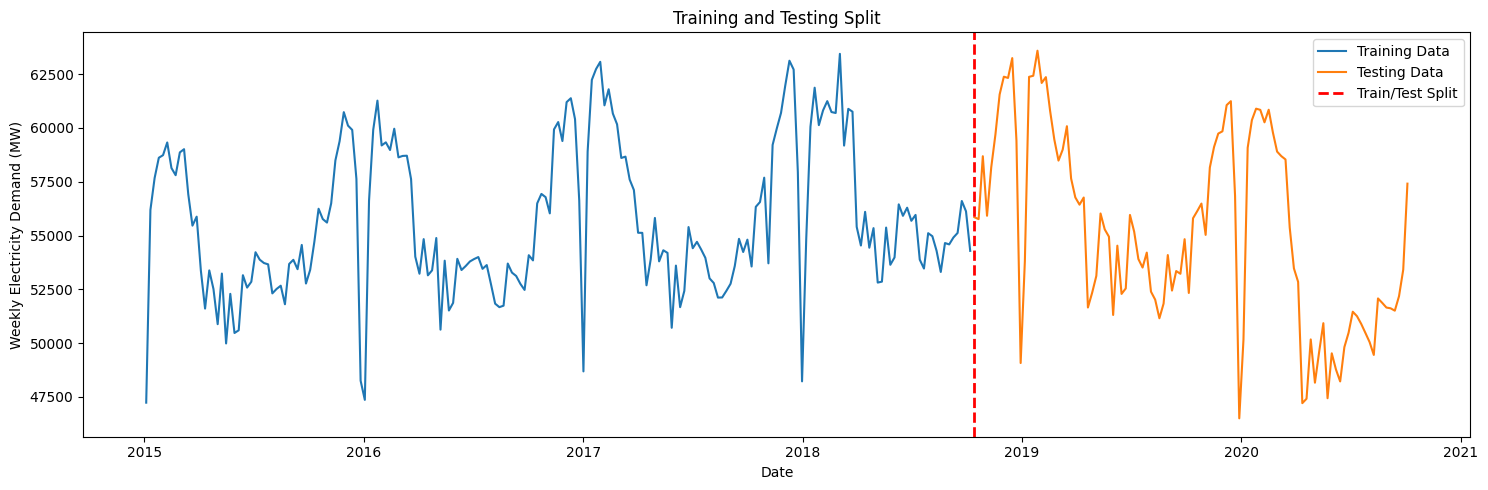

In [10]:
# TRAIN-TEST SPLIT

data = weekly.copy()

print("Total weekly observations:", len(data))

test_size = 104  # using two years data

train = data.iloc[:-test_size]

test = data.iloc[-test_size:]

print("\nTraining observations :", len(train))
print("Testing observations  :", len(test))

print("\nTraining period")
print(train.index.min(), "to", train.index.max())

print("\nTesting period")
print(test.index.min(), "to", test.index.max())

plt.figure(figsize=(15,5))

# Visualising split

plt.plot(train.index, train["Load"], label="Training Data")

plt.plot(test.index, test["Load"], label="Testing Data")

plt.axvline(
    x=test.index[0],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Train/Test Split"
)

plt.title("Training and Testing Split")

plt.xlabel("Date")

plt.ylabel("Weekly Electricity Demand (MW)")

plt.legend()

plt.tight_layout()

plt.show()